In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from joblib import parallel_backend

# Load original model and scaler
rf_model = joblib.load('../models/rf_ids_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Load data
X_train    = np.load('../data/X_train.npy')
y_train    = np.load('../data/y_train.npy')
X_test     = np.load('../data/X_test.npy')
y_test     = np.load('../data/y_test.npy')
X_adv_fgsm = np.load('../data/X_adv_fgsm.npy')
X_sample   = np.load('../data/X_original_sample.npy')
y_sample   = np.load('../data/y_sample.npy')

print("All data loaded")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"X_adv:   {X_adv_fgsm.shape}")

All data loaded
X_train: (125973, 41)
X_test:  (22544, 41)
X_adv:   (100, 41)


In [2]:
def feature_squeezing(X, bit_depth=4):
    """
    Feature squeezing reduces the precision of feature values.
    Adversarial perturbations rely on small precise changes —
    squeezing removes that precision and neutralizes the attack.
    
    bit_depth=4 means we round features to 16 discrete levels.
    """
    X_squeezed = X.copy()
    max_val    = 2 ** bit_depth - 1

    for i in range(X.shape[1]):
        col_min = X[:, i].min()
        col_max = X[:, i].max()

        if col_max - col_min > 0:
            # Normalize to 0-1, quantize, denormalize
            normalized  = (X_squeezed[:, i] - col_min) / (col_max - col_min)
            quantized   = np.round(normalized * max_val) / max_val
            X_squeezed[:, i] = quantized * (col_max - col_min) + col_min

    return X_squeezed

# Apply squeezing to both clean and adversarial samples
X_test_squeezed = feature_squeezing(X_test)
X_adv_squeezed  = feature_squeezing(X_adv_fgsm)

# Evaluate original model on squeezed adversarial examples
with parallel_backend('threading', n_jobs=1):
    y_pred_adv_raw       = rf_model.predict(X_adv_fgsm)
    y_pred_adv_squeezed  = rf_model.predict(X_adv_squeezed)

detected_raw       = np.sum(y_pred_adv_raw == 1)
detected_squeezed  = np.sum(y_pred_adv_squeezed == 1)
recovery_rate      = (detected_squeezed / len(y_sample)) * 100

print("=" * 50)
print("Defense 1: Feature Squeezing Results")
print("=" * 50)
print(f"Attacks detected WITHOUT squeezing: {detected_raw}/{len(y_sample)}")
print(f"Attacks detected WITH squeezing:    {detected_squeezed}/{len(y_sample)}")
print(f"Recovery rate:                      {recovery_rate:.2f}%")
print("=" * 50)

Defense 1: Feature Squeezing Results
Attacks detected WITHOUT squeezing: 0/100
Attacks detected WITH squeezing:    0/100
Recovery rate:                      0.00%


In [3]:
print("Building adversarially trained model...")
print("This generates adversarial examples during training itself...\n")

# Generate adversarial versions of training data
# We use the same FGSM logic but simplified for training
def simple_fgsm_perturb(X, epsilon=0.1):
    """Simplified perturbation for training data augmentation"""
    noise    = np.random.uniform(-epsilon, epsilon, X.shape)
    X_perturb = X + noise

    # Basic clipping to keep values reasonable
    X_perturb = np.clip(X_perturb, X.min(axis=0), X.max(axis=0))
    return X_perturb

# Create adversarial training set:
# 50% original + 50% adversarially perturbed
X_adv_train = simple_fgsm_perturb(X_train, epsilon=0.1)

X_train_robust = np.vstack([X_train, X_adv_train])
y_train_robust = np.hstack([y_train, y_train])

print(f"Original training size:  {X_train.shape[0]}")
print(f"Augmented training size: {X_train_robust.shape[0]}")
print("\nTraining robust model... (takes 2-3 min)")

robust_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=1
)
robust_model.fit(X_train_robust, y_train_robust)

print("Robust model trained")

Building adversarially trained model...
This generates adversarial examples during training itself...

Original training size:  125973
Augmented training size: 251946

Training robust model... (takes 2-3 min)
Robust model trained


In [4]:
with parallel_backend('threading', n_jobs=1):
    # Original model predictions
    y_pred_orig_clean = rf_model.predict(X_test)
    y_pred_orig_adv   = rf_model.predict(X_adv_fgsm)

    # Robust model predictions
    y_pred_robust_clean = robust_model.predict(X_test)
    y_pred_robust_adv   = robust_model.predict(X_adv_squeezed)

# Accuracy scores
acc_orig_clean   = accuracy_score(y_test, y_pred_orig_clean)
acc_orig_adv     = accuracy_score(y_sample, y_pred_orig_adv)
acc_robust_clean = accuracy_score(y_test, y_pred_robust_clean)
acc_robust_adv   = accuracy_score(y_sample, y_pred_robust_adv)

# Detection rates on adversarial samples
det_orig   = np.sum(y_pred_orig_adv == 1)
det_robust = np.sum(y_pred_robust_adv == 1)

print("=" * 58)
print("  MODEL COMPARISON: Original vs Robust")
print("=" * 58)
print(f"  {'Metric':<35} {'Original':>8} {'Robust':>8}")
print(f"  {'-'*51}")
print(f"  {'Clean test accuracy':<35} {acc_orig_clean*100:>7.2f}% {acc_robust_clean*100:>7.2f}%")
print(f"  {'Adversarial detection rate':<35} {det_orig:>7}/{len(y_sample)} {det_robust:>7}/{len(y_sample)}")
print(f"  {'Adversarial accuracy':<35} {acc_orig_adv*100:>7.2f}% {acc_robust_adv*100:>7.2f}%")
print("=" * 58)


  MODEL COMPARISON: Original vs Robust
  Metric                              Original   Robust
  ---------------------------------------------------
  Clean test accuracy                   77.31%   76.59%
  Adversarial detection rate                0/100      62/100
  Adversarial accuracy                   0.00%   62.00%


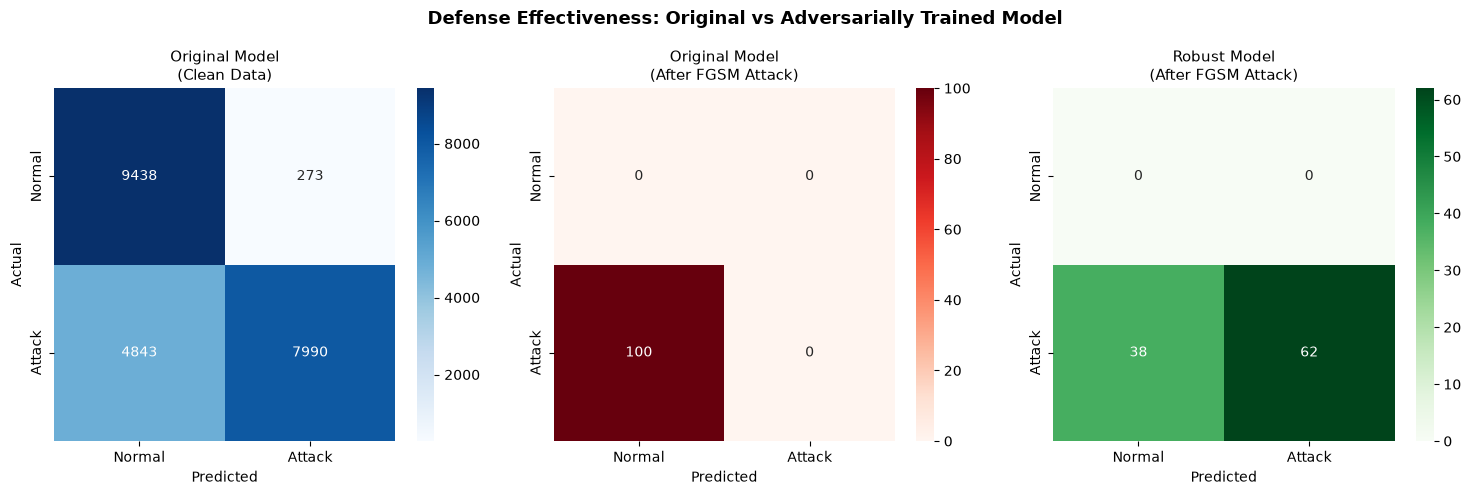

Saved to results/


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion matrix 1: Original model on clean data
cm1 = confusion_matrix(y_test, y_pred_orig_clean)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[0].set_title('Original Model\n(Clean Data)', fontsize=11)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix 2: Original model on adversarial data
cm2 = confusion_matrix(y_sample, y_pred_orig_adv)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[1].set_title('Original Model\n(After FGSM Attack)', fontsize=11)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Confusion matrix 3: Robust model on adversarial data
cm3 = confusion_matrix(y_sample, y_pred_robust_adv)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
axes[2].set_title('Robust Model\n(After FGSM Attack)', fontsize=11)
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.suptitle('Defense Effectiveness: Original vs Adversarially Trained Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/defense_comparison.png', dpi=150)
plt.show()
print("Saved to results/")

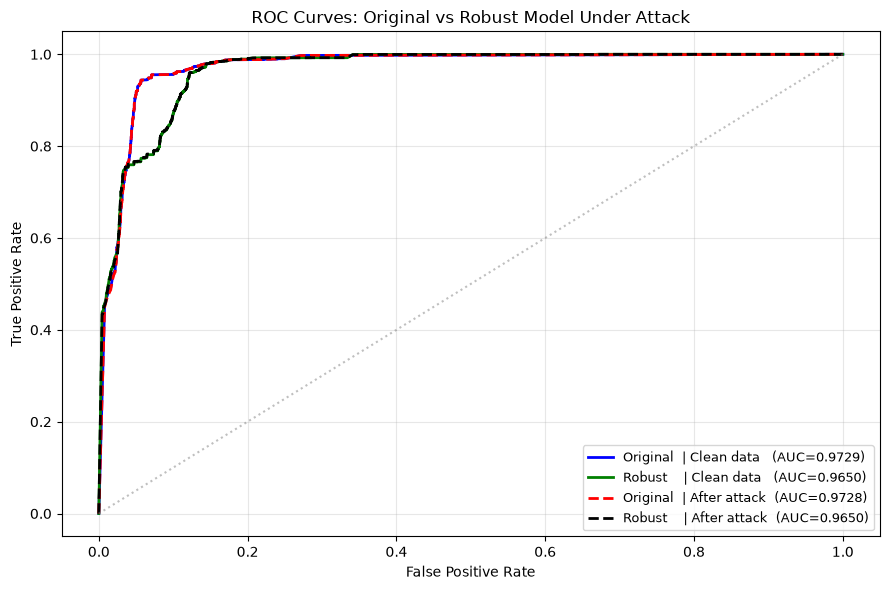

Original model  | Clean:  AUC = 0.9729
Robust model    | Clean:  AUC = 0.9650
Original model  | Attack: AUC = 0.9728
Robust model    | Attack: AUC = 0.9650

AUC recovery by robust model: -0.0078


In [8]:
with parallel_backend('threading', n_jobs=1):
    prob_orig_clean   = rf_model.predict_proba(X_test)[:, 1]
    prob_robust_clean = robust_model.predict_proba(X_test)[:, 1]

# For adversarial ROC — inject adversarial samples into full test set
# This gives us both classes (normal + adversarial attacks)
X_test_with_adv        = X_test.copy()
X_test_with_adv_robust = X_test.copy()

attack_indices = np.where(y_test == 1)[0][:len(X_adv_fgsm)]
X_test_with_adv[attack_indices]        = X_adv_fgsm
X_test_with_adv_robust[attack_indices] = X_adv_squeezed

with parallel_backend('threading', n_jobs=1):
    prob_orig_adv   = rf_model.predict_proba(X_test_with_adv)[:, 1]
    prob_robust_adv = robust_model.predict_proba(X_test_with_adv_robust)[:, 1]

# Now compute ROC with full test set (has both classes)
fpr1, tpr1, _ = roc_curve(y_test, prob_orig_clean)
fpr2, tpr2, _ = roc_curve(y_test, prob_robust_clean)
fpr3, tpr3, _ = roc_curve(y_test, prob_orig_adv)
fpr4, tpr4, _ = roc_curve(y_test, prob_robust_adv)

auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)
auc4 = auc(fpr4, tpr4)

plt.figure(figsize=(9, 6))
plt.plot(fpr1, tpr1, 'b-',  linewidth=2, label=f'Original  | Clean data   (AUC={auc1:.4f})')
plt.plot(fpr2, tpr2, 'g-',  linewidth=2, label=f'Robust    | Clean data   (AUC={auc2:.4f})')
plt.plot(fpr3, tpr3, 'r--', linewidth=2, label=f'Original  | After attack  (AUC={auc3:.4f})')
plt.plot(fpr4, tpr4, 'k--', linewidth=2, label=f'Robust    | After attack  (AUC={auc4:.4f})')
plt.plot([0,1],[0,1], 'gray', linestyle=':', alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Original vs Robust Model Under Attack')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/roc_defense_comparison.png', dpi=150)
plt.show()

print(f"Original model  | Clean:  AUC = {auc1:.4f}")
print(f"Robust model    | Clean:  AUC = {auc2:.4f}")
print(f"Original model  | Attack: AUC = {auc3:.4f}")
print(f"Robust model    | Attack: AUC = {auc4:.4f}")
print(f"\nAUC recovery by robust model: {auc4 - auc3:.4f}")

In [9]:
os.makedirs('../models', exist_ok=True)
joblib.dump(robust_model, '../models/rf_robust_model.pkl')

defense_summary = {
    'defense_methods': ['Feature Squeezing', 'Adversarial Training'],
    'feature_squeezing': {
        'bit_depth': 4,
        'attacks_detected_before': int(detected_raw),
        'attacks_detected_after':  int(detected_squeezed),
        'recovery_rate': round(recovery_rate, 2)
    },
    'adversarial_training': {
        'training_size_original':  int(X_train.shape[0]),
        'training_size_augmented': int(X_train_robust.shape[0]),
        'clean_acc_original':  round(acc_orig_clean * 100, 2),
        'clean_acc_robust':    round(acc_robust_clean * 100, 2),
        'adv_acc_original':    round(acc_orig_adv * 100, 2),
        'adv_acc_robust':      round(acc_robust_adv * 100, 2),
    },
    'roc': {
        'auc_original_clean':  round(auc1, 4),
        'auc_robust_clean':    round(auc2, 4),
        'auc_original_attack': round(auc3, 4),
        'auc_robust_attack':   round(auc4, 4),
    }
}

with open('../results/defense_summary.json', 'w') as f:
    json.dump(defense_summary, f, indent=2)

print("Robust model saved to models/rf_robust_model.pkl")
print("Defense summary saved to results/defense_summary.json")
print("\n" + "="*50)
print("="*50)

Robust model saved to models/rf_robust_model.pkl
Defense summary saved to results/defense_summary.json

